# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3626s 21us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

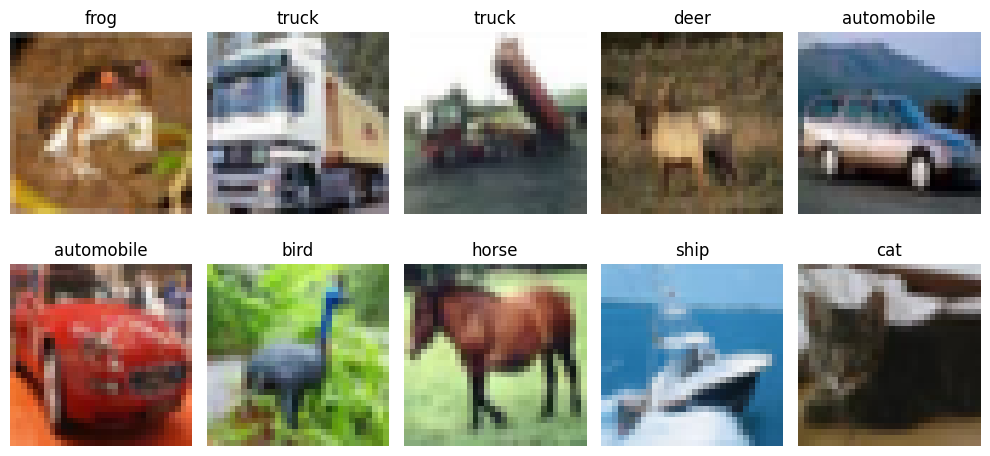

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.2632 - loss: 2.0090 - val_accuracy: 0.3318 - val_loss: 1.8856
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3170 - loss: 1.8709 - val_accuracy: 0.3714 - val_loss: 1.7568
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.3319 - loss: 1.8287 - val_accuracy: 0.3698 - val_loss: 1.7624
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3462 - loss: 1.7918 - val_accuracy: 0.3508 - val_loss: 1.7787
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.3543 - loss: 1.7693 - val_accuracy: 0.3814 - val_loss: 1.7552
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.3607 - loss: 1.7464 - val_accuracy: 0.3720 - val_loss: 1.7644
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.3644 - loss: 1.7360 - val_accuracy: 0.3758 - val_loss: 1.7524
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3725 - loss: 1.7188 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4158 - loss: 1.6422
ANN Test Accuracy: 0.415800005197525


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 130ms/step - accuracy: 0.4690 - loss: 1.4912 - val_accuracy: 0.5676 - val_loss: 1.2058
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6064 - loss: 1.1243 - val_accuracy: 0.5974 - val_loss: 1.1604
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.6713 - loss: 0.9464 - val_accuracy: 0.6340 - val_loss: 1.0864
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 137ms/step - accuracy: 0.7145 - loss: 0.8296 - val_accuracy: 0.6438 - val_loss: 1.0179
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.7472 - loss: 0.7225 - val_accuracy: 0.7154 - val_loss: 0.8236
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7751 - loss: 0.6436 - val_accuracy: 0.7092 - val_loss: 0.8783
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7974 - loss: 0.5748 - val_accuracy: 0.7208 - val_loss: 0.8341
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.8152 - loss:

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6852 - loss: 1.1452
CNN Test Accuracy: 0.6851999759674072


## 📈 Compare Learning Curves

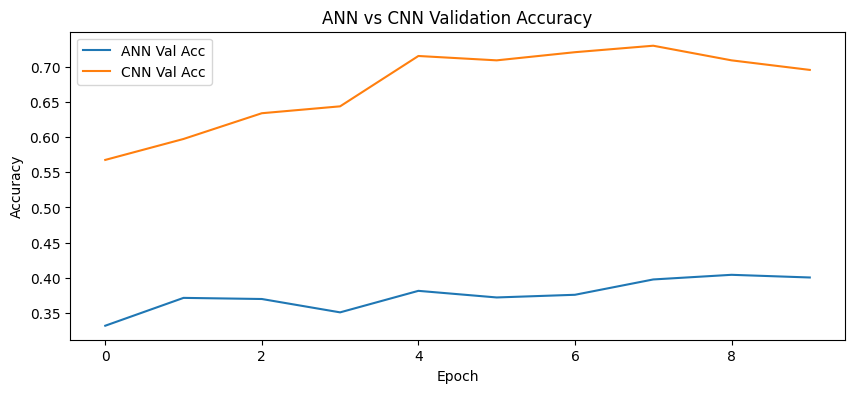

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.3761 - loss: 1.7052 - val_accuracy: 0.4762 - val_loss: 1.4885
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 56ms/step - accuracy: 0.4650 - loss: 1.4882 - val_accuracy: 0.5364 - val_loss: 1.2817
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.4989 - loss: 1.3997 - val_accuracy: 0.5738 - val_loss: 1.1839
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.5228 - loss: 1.3391 - val_accuracy: 0.5826 - val_loss: 1.1569
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 58ms/step - accuracy: 0.5407 - loss: 1.3047 - val_accuracy: 0.5972 - val_loss: 1.1296
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.5497 - loss: 1.2698 - val_accuracy: 0.5906 - val_loss: 1.1760
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.5578 - loss: 1.2478 - val_accuracy: 0.6224 - val_loss: 1.0836
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.5729 -

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4158
1,CNN,0.6852


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

**Assignment Modification**
 1. Added EarlyStopping callback to stop training automaticallywhen validation loss stops improving

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**Assignment Task 1:**
1. Modified ANN by increasing the number of hidden layers and neurons to improve learning capability.
2. Architecture changed from: 512 -> 256 -> Output to 1024 -> 512 -> 256 -> 128 -> Output

In [13]:
modified_ann = models.Sequential([

    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')

])

modified_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modified_ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

**Assignment Task 2:**
1. Increased training epochs from 10 to 20
2. Added EarlyStopping callback

In [14]:
modified_ann_history = modified_ann.fit(

    x_train_flat,
    y_train,

    epochs=20,

    validation_split=0.1,

    batch_size=64,

    callbacks=[early_stop]

)

modified_ann_loss, modified_ann_acc = modified_ann.evaluate(
    x_test_flat,
    y_test
)

print("Modified ANN Accuracy :", modified_ann_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 70ms/step - accuracy: 0.2466 - loss: 2.0310 - val_accuracy: 0.3078 - val_loss: 1.8762
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.3181 - loss: 1.8688 - val_accuracy: 0.3586 - val_loss: 1.7753
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.3401 - loss: 1.8163 - val_accuracy: 0.3668 - val_loss: 1.7461
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.3549 - loss: 1.7809 - val_accuracy: 0.4002 - val_loss: 1.7365
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.3656 - loss: 1.7461 - val_accuracy: 0.4064 - val_loss: 1.6904
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 68ms/step - accuracy: 0.3803 - loss: 1.7183 - val_accuracy: 0.4112 - val_loss: 1.6662
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 0.3847 - loss: 1.7016 - val_accuracy: 0.4238 - val_loss: 1.6621
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3923 - loss: 1.6821 - 

**Assignment Task 3:**
1. Modified CNN filters from 32 -> 64 -> 128 to 64 -> 128 -> 256 for better feature extraction.


In [15]:
modified_cnn = models.Sequential([

    layers.Conv2D(64,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')

])

modified_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modified_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,290 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 384 (1.50 KB)

**Assignment Task 4:**
1. Increased CNN training epochs from 10 to 20
2. Added EarlyStopping callback

In [16]:
# ============================================================
# Assignment Task 4:
# Increased CNN training epochs from 10 to 20
# Added EarlyStopping callback
# ============================================================

modified_cnn_history = modified_cnn.fit(

    x_train_norm,
    y_train,

    epochs=20,

    validation_split=0.1,

    batch_size=64,

    callbacks=[early_stop]

)

modified_cnn_loss, modified_cnn_acc = modified_cnn.evaluate(
    x_test_norm,
    y_test
)

print("Modified CNN Accuracy :", modified_cnn_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 241s 338ms/step - accuracy: 0.4579 - loss: 1.5315 - val_accuracy: 0.4796 - val_loss: 1.4129
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 241s 342ms/step - accuracy: 0.6106 - loss: 1.1216 - val_accuracy: 0.6286 - val_loss: 1.0352
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 235s 334ms/step - accuracy: 0.6767 - loss: 0.9426 - val_accuracy: 0.6082 - val_loss: 1.1098
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 331ms/step - accuracy: 0.7206 - loss: 0.8041 - val_accuracy: 0.6840 - val_loss: 0.9138
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 237s 336ms/step - accuracy: 0.7586 - loss: 0.6969 - val_accuracy: 0.7108 - val_loss: 0.8835
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 236s 335ms/step - accuracy: 0.7914 - loss: 0.5956 - val_accuracy: 0.7042 - val_loss: 0.9087
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 238s 338ms/step - accuracy: 0.8209 - loss: 0.5106 - val_accuracy: 0.6404 - val_loss: 1.1507
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 236s 335ms/step - accuracy: 0.8462 -

**Assignment Task 5:**

1. Training CNN using Data Augmentation to improve generalization and reduce overfitting.

In [20]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy :", aug_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.6050 - loss: 1.1198 - val_accuracy: 0.6510 - val_loss: 0.9830
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.6116 - loss: 1.1064 - val_accuracy: 0.6680 - val_loss: 0.9546
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 94ms/step - accuracy: 0.6137 - loss: 1.0946 - val_accuracy: 0.6650 - val_loss: 0.9475
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.6183 - loss: 1.0902 - val_accuracy: 0.6652 - val_loss: 0.9349
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.6220 - loss: 1.0780 - val_accuracy: 0.6628 - val_loss: 0.9422
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 97ms/step - accuracy: 0.6215 - loss: 1.0803 - val_accuracy: 0.6648 - val_loss: 0.9570
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 94ms/step - accuracy: 0.6274 - loss: 1.0676 - val_accuracy: 0.6580 - val_loss: 0.9613
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 96ms/step - accuracy: 0.6273 - loss: 1.0614 - 

**Final Comparison of Modified Models**

In [21]:
comparison = pd.DataFrame({

    "Model":[
        "Original ANN",
        "Modified ANN",
        "Original CNN",
        "Modified CNN",
        "Augmented CNN"
    ],

    "Test Accuracy":[

        ann_test_acc,

        modified_ann_acc,

        cnn_test_acc,

        modified_cnn_acc,

        aug_acc
    ]

})

comparison

,Model,Test Accuracy
0,Original ANN,0.4158
1,Modified ANN,0.4708
2,Original CNN,0.6852
3,Modified CNN,0.7065
4,Augmented CNN,0.6793


**Comparing Validation Accuracy of Modified ANN and CNN**

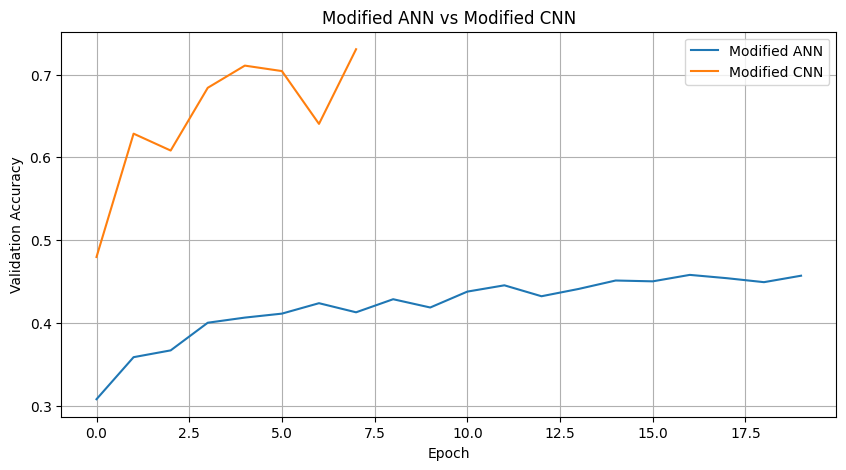

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    modified_ann_history.history['val_accuracy'],
    label='Modified ANN'
)

plt.plot(
    modified_cnn_history.history['val_accuracy'],
    label='Modified CNN'
)

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title("Modified ANN vs Modified CNN")

plt.legend()

plt.grid(True)

plt.show()

**Final Conclusion** :

In [25]:
print("Modified ANN Accuracy :", modified_ann_acc)

print("Modified CNN Accuracy :", modified_cnn_acc)

print("Augmented CNN Accuracy :", aug_acc)

Modified ANN Accuracy : 0.4708000123500824
Modified CNN Accuracy : 0.7064999938011169
Augmented CNN Accuracy : 0.6793000102043152


**Observation:**

* The Modified CNN achieved significantly higher validation accuracy than the Modified ANN.
* Increasing the CNN filters (64->128->256) improved feature extraction and learning performance.
* The Modified ANN showed some improvement after adding additional hidden layers but still performed lower because ANN does not preserve spatial information in images.
* The Modified CNN reached approximately 73% validation accuracy, whereas the Modified ANN reached around 46%, demonstrating the effectiveness of convolutional neural networks for image classification.